<a href="https://colab.research.google.com/github/aarya078/July26/blob/main/July6dataTRAINING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#importing dependencies
import pandas  as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn import metrics
#importing the data

#linear regression works only on numerical data not strings or objects

In [ ]:
#loading data from csv file to pandas dataframes
car_dataset = pd.read_csv('/content/car data.csv')


In [ ]:
#importing the first 5 rows ofthe dataframe
car_dataset.head()
#obtaining the required output for analysis

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [5]:
#obtainingn last 5 dataset from the list of car dataset!
car_dataset.tail()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [7]:
#generating a random row from the given dataset of cars!
#sample() function is to provide a random column or row from the given dataframe
car_dataset.sample()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
54,innova,2005,2.75,10.21,90000,Petrol,Individual,Manual,0


In [8]:
#checking the number of rows and columns
car_dataset.shape
#obtaining dimensional data of dataframe named car_dataset

(301, 9)

In [9]:
#obtaining certain informations of each columns and further details!
car_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [10]:
#calculating the sumtotal of null values or missing values of the dataset
car_dataset.isnull().sum()
#no null values have been obtained

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [11]:
#analyzing the distribution of data in different categories of provided dataset
#selecting 3 columns!
print(car_dataset.Fuel_Type.value_counts())

print(car_dataset.Seller_Type.value_counts())
print(car_dataset.Transmission.value_counts())

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64
Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64


ENCODING 3 COLUMNS!!

In [12]:
#encoding the certain categories of data
#1."Fuel_type" column encoding
car_dataset.replace({'Fuel_Type':{'Petrol':0,'Diesel':1,'CNG':2}},inplace=True)

#2."Seller_Type" column encoding
car_dataset.replace({'Seller_Type':{'Dealer':0,'Individual':1}},inplace=True)
#3. "Transmission " column encoding
car_dataset.replace({'Transmission':{'Manual':0,'Automatic':1}},inplace=True)

/tmp/ipykernel_1006/4105170107.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  car_dataset.replace({'Fuel_Type':{'Petrol':0,'Diesel':1,'CNG':2}},inplace=True)
/tmp/ipykernel_1006/4105170107.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  car_dataset.replace({'Seller_Type':{'Dealer':0,'Individual':1}},inplace=True)
/tmp/ipykernel_1006/4105170107.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=

In [13]:
#CHECKING the encoding result
car_dataset.head()
#changes are clearly visible

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,0,0,0,0
1,sx4,2013,4.75,9.54,43000,1,0,0,0
2,ciaz,2017,7.25,9.85,6900,0,0,0,0
3,wagon r,2011,2.85,4.15,5200,0,0,0,0
4,swift,2014,4.60,6.87,42450,1,0,0,0


In [14]:
car_dataset.shape
#no alteration in the order of rows and columns

(301, 9)

SPLITTING THE DATA AND THE TARGET

In [17]:
X = car_dataset.drop(['Car_Name','Selling_Price'],axis=1) #axis=1 to make changes in column
#droping 2 columns
Y = car_dataset['Selling_Price']
#adding a particular column to Y
#to predict the selling price

In [16]:
# printing the assigned dataset TO 'X'
print(X)

     Year  Present_Price  Kms_Driven  ...  Seller_Type  Transmission  Owner
0    2014           5.59       27000  ...            0             0      0
1    2013           9.54       43000  ...            0             0      0
2    2017           9.85        6900  ...            0             0      0
3    2011           4.15        5200  ...            0             0      0
4    2014           6.87       42450  ...            0             0      0
..    ...            ...         ...  ...          ...           ...    ...
296  2016          11.60       33988  ...            0             0      0
297  2015           5.90       60000  ...            0             0      0
298  2009          11.00       87934  ...            0             0      0
299  2017          12.50        9000  ...            0             0      0
300  2016           5.90        5464  ...            0             0      0

[301 rows x 7 columns]


In [18]:
#printing the assigned column to "Y"
print(Y)

0       3.35
1       4.75
2       7.25
3       2.85
4       4.60
       ...  
296     9.50
297     4.00
298     3.35
299    11.50
300     5.30
Name: Selling_Price, Length: 301, dtype: float64


SPLITTING TRAINING DATA AND TESTING DATA

In [19]:
#90% DATA is used for TRAINING AND REST 10% for TESTING
#SPLITTING TRAINING AND TEST DATA
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.1, random_state=2)

TRAINING THE MODEL!!!

1. LINEAR REGRESSION

In [20]:
# loading and providing the linear regression model
lin_reg_model = LinearRegression()

In [21]:
lin_reg_model.fit(X_train,Y_train)

LinearRegression()

MODEL EVALUATION

In [22]:
#making predictions on data training
training_data_prediction = lin_reg_model.predict(X_train)

In [23]:
# calculating R- squared error
error_score = metrics.r2_score(Y_train, training_data_prediction)
print("R squared Error : ", error_score)
# MORE is closeness to 1, more is the efficiency!!

R squared Error :  0.8799451660493711


VISUALIZING THE ACTUAL PRICES AND PREDICTED PRICES

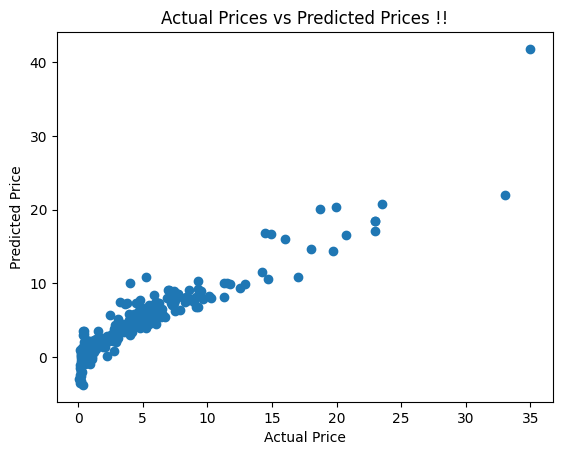

In [24]:
# usage of matplotlib!
plt.scatter(Y_train, training_data_prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Prices vs Predicted Prices !!")
plt.show()
#the following graph contains a ouliar, one that is located beyond the usuals !!

In [25]:
# making predictions on the TRAINING DATA
test_data_prediction = lin_reg_model.predict(X_test)

In [26]:
#R squared ERROR
error_score = metrics.r2_score(Y_test, test_data_prediction)
print("R squared Error : ", error_score)

R squared Error :  0.8365766715027051


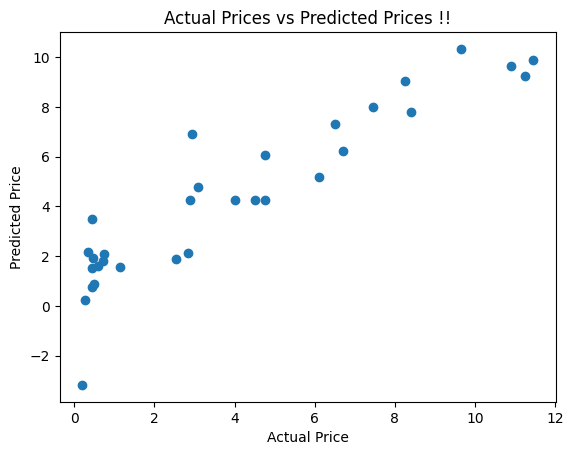

In [27]:
#visualiing the data
plt.scatter(Y_test, test_data_prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Prices vs Predicted Prices !!")
plt.show()
#an outliar is present at the 0-2 initial

2.LASSO REGRESSION


In [28]:
#LOADING the linear regression model just removes not useful datas
lass_reg_model = Lasso()

In [29]:
lass_reg_model.fit(X_train, Y_train) #fitting in the required range

Lasso()

MODEL EVALUATION

In [30]:
#making predictions on TRAINING DATA
training_data_prediction = lass_reg_model.predict(X_train)

In [31]:
#R squared ERROR
error_score = metrics.r2_score(Y_train, training_data_prediction)
print("R squared Error : ", error_score)

R squared Error :  0.8427856123435794


VISUALIZING THE ACTUAL AND PREDICTED PRICES

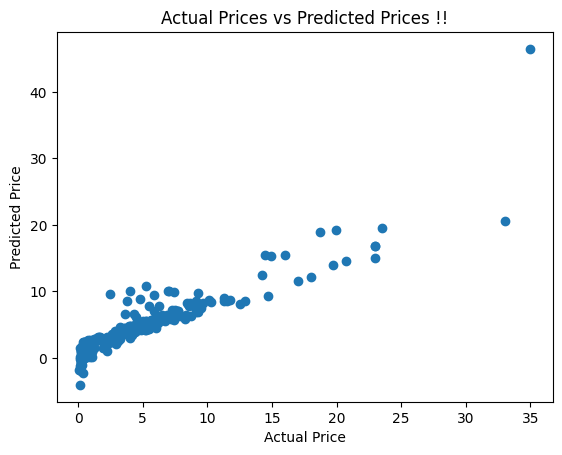

In [32]:
plt.scatter(Y_train, training_data_prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Prices vs Predicted Prices !!")
plt.show()
#an outliar is present

In [33]:
#making prediction on testing data
test_data_prediction = lass_reg_model.predict(X_test)

In [34]:
# R squared ERROR
error_score = metrics.r2_score(Y_test, test_data_prediction)
print("R squared Error : ", error_score)
#

R squared Error :  0.8709167941173195


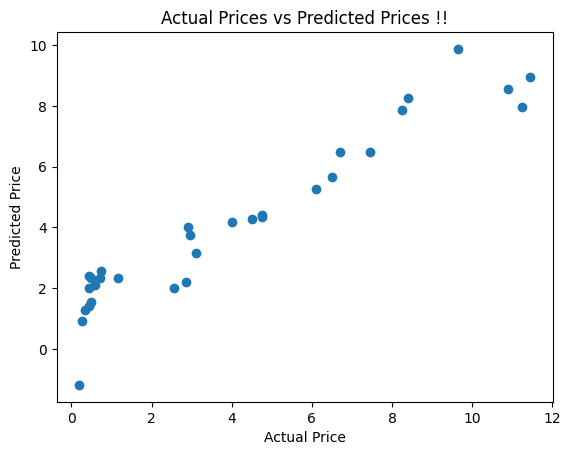

In [35]:
#data visualization
plt.scatter(Y_test, test_data_prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Prices vs Predicted Prices !!")
plt.show()
#an